# 🦴 Osteoporosis Detection Using MLP Framework
---
**Institution:** NUST College of Electrical & Mechanical Engineering (CEME)  
**Course:** CS-878 — Deep Learning  
**Assignment:** Assignment 1  
**Instructor:** Dr. Usman Akram  
**Submission Date:** 22 February 2026  

| Field | Details |
|---|---|
| **Student 1** | Aqdas Hassan — Reg# 499341 |
| **Student 2** | Muhammad Soban Shaukat — Reg# 538822 |

---
> **Objective:** Develop an MLP-based framework for 3-class osteoporosis detection
> (Normal / Osteopenia / Osteoporosis) using the NHANES population health dataset.


---
## ⚙️ Step 1: Project Setup & Data Loading
---
### 1.1 Library Imports
Importing all required libraries for data handling, visualization, and deep learning.




In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
print("All libraries loaded  ")


All libraries loaded  


### 1.2 Dataset
- **Source:** NHANES (National Health & Nutrition Examination Survey), CDC
- **Cycles:** 1999–2018 combined cohort
- **Samples:** 11,943 | **Features:** 14 | **Classes:** 3
- **Target:** `WHO_Class` → Normal, Osteopenia, Osteoporosis

In [47]:
url = "https://docs.google.com/spreadsheets/d/1jJPKzuA5tZ7a1NFikNb0E8WoyU_feoPG/export?format=csv"
df = pd.read_csv(url)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nClass Distribution:\n", df['WHO_Class'].value_counts())
print("\nMissing Values:\n", df.isnull().sum())
df.head()


Shape: (11943, 15)

Columns: ['Alkaline_Phosphatase', 'Smoking', 'Diabetes', 'Vitamin_D', 'Hematocrit_pct', 'BMI', 'Menopause', 'Trauma', 'Hemoglobin_g_dL', 'Age', 'Calcium', 'Weight_kg', 'Gender', 'Height_cm', 'WHO_Class']

Class Distribution:
 WHO_Class
Normal          4030
Osteopenia      3988
Osteoporosis    3925
Name: count, dtype: int64

Missing Values:
 Alkaline_Phosphatase    0
Smoking                 0
Diabetes                0
Vitamin_D               0
Hematocrit_pct          0
BMI                     0
Menopause               0
Trauma                  0
Hemoglobin_g_dL         0
Age                     0
Calcium                 0
Weight_kg               0
Gender                  0
Height_cm               0
WHO_Class               0
dtype: int64


,Alkaline_Phosphatase,Smoking,Diabetes,Vitamin_D,Hematocrit_pct,BMI,Menopause,Trauma,Hemoglobin_g_dL,Age,Calcium,Weight_kg,Gender,Height_cm,WHO_Class
0,74.00,0,0,59.20,38.90,21.34,1,0,13.00,9.00,9.60,37.70,2,132.90,Osteoporosis
1,66.00,0,0,83.50,46.00,22.46,0,0,15.20,85.00,10.10,55.50,2,157.20,Normal
2,58.04,0,0,41.06,39.68,24.09,1,0,13.57,96.56,9.66,46.19,2,129.58,Osteopenia
3,74.00,0,0,81.00,42.10,19.38,1,0,14.60,8.00,9.60,32.90,2,130.30,Osteoporosis
4,81.99,0,0,58.33,41.33,14.08,1,0,14.12,11.92,9.61,39.28,2,147.57,Osteoporosis


---
## 🔧 Step 2: Data Preprocessing
---
The following preprocessing steps are applied before model training:

| Step | Detail |
|---|---|
| **Label Encoding** | WHO_Class → integer labels (0, 1, 2) |
| **Feature Scaling** | StandardScaler — zero mean, unit variance |
| **Data Split** | 80% Train → 64% Train + 16% Validation \| 20% Test |
| **DataLoaders** | Batch size = 64, shuffled for training |


In [48]:
# Encode target
le = LabelEncoder()
df['label'] = le.fit_transform(df['WHO_Class'])
print("Class Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# Features and target
X = df.drop(columns=['WHO_Class', 'label']).values
y = df['label'].values

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)

print("Feature Shape:", X.shape)
print("Label Shape:", y.shape)


Class Mapping: {'Normal': np.int64(0), 'Osteopenia': np.int64(1), 'Osteoporosis': np.int64(2)}
Feature Shape: (11943, 14)
Label Shape: (11943,)


In [49]:
# 80-20 split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

# Split train into 80% train, 20% val (i.e., 64/16/20 overall)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20, random_state=42, stratify=y_train_full)

print(f"Train:      {X_train.shape[0]} samples")
print(f"Validation: {X_val.shape[0]} samples")
print(f"Test:       {X_test.shape[0]} samples")


Train:      7643 samples
Validation: 1911 samples
Test:       2389 samples


In [50]:
def to_loader(X, y, batch_size=64, shuffle=True):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.long)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)

train_loader = to_loader(X_train, y_train)
val_loader   = to_loader(X_val,   y_val,   shuffle=False)
test_loader  = to_loader(X_test,  y_test,  shuffle=False)

print("DataLoaders ready  ")


DataLoaders ready  


---
## 📊 Task 1: Data Visualization
---
Visual analysis of four clinically relevant features:
**Age, BMI, Vitamin D, Calcium**

| Plot Type | Purpose |
|---|---|
| **Histogram** | Feature distribution — overall and class-wise |
| **Scatter Plot** | Pairwise correlation between features |
| **Box Plot** | Spread, median, and outliers per class |

> Each plot is saved individually under `plots/` for report use.


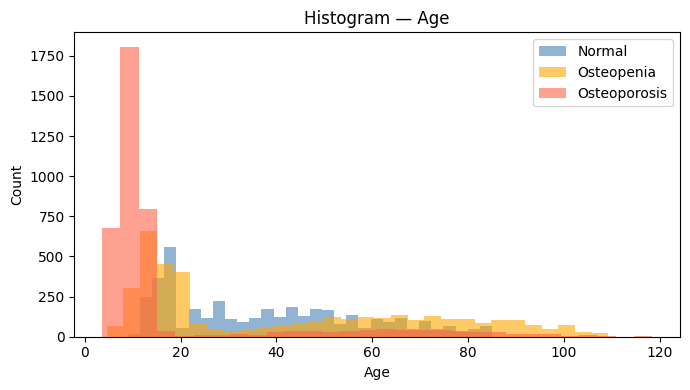

Saved: plots/histograms/hist_Age.png  


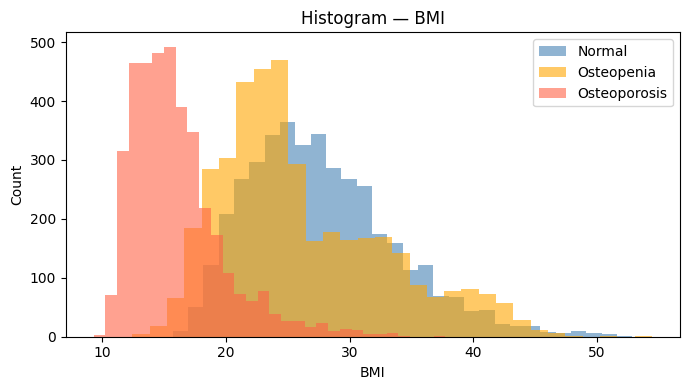

Saved: plots/histograms/hist_BMI.png  


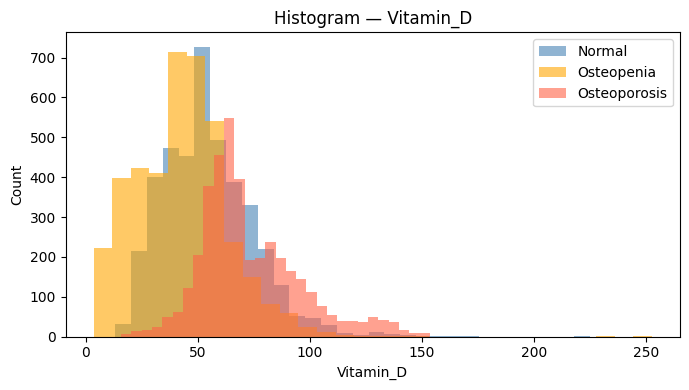

Saved: plots/histograms/hist_Vitamin_D.png  


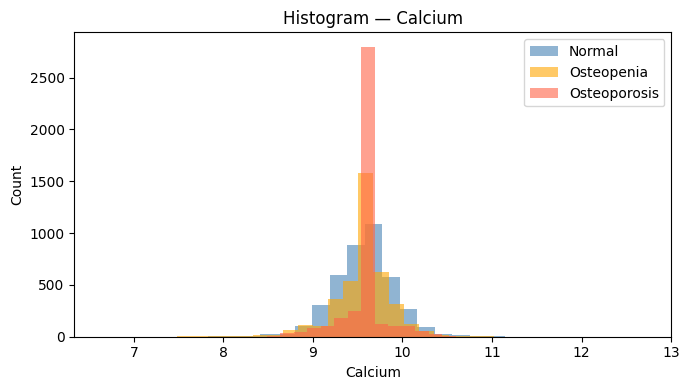

Saved: plots/histograms/hist_Calcium.png  


In [51]:
import os
os.makedirs("plots/histograms", exist_ok=True)

features = ['Age', 'BMI', 'Vitamin_D', 'Calcium']
classes  = ['Normal', 'Osteopenia', 'Osteoporosis']
colors   = ['steelblue', 'orange', 'tomato']

for feat in features:
    plt.figure(figsize=(7, 4))
    for cls, col in zip(classes, colors):
        subset = df[df['WHO_Class'] == cls][feat]
        plt.hist(subset, bins=30, alpha=0.6, label=cls, color=col)
    plt.title(f'Histogram — {feat}')
    plt.xlabel(feat); plt.ylabel('Count')
    plt.legend(); plt.tight_layout()
    plt.savefig(f"plots/histograms/hist_{feat}.png", dpi=150)
    plt.show()
    print(f"Saved: plots/histograms/hist_{feat}.png  ")


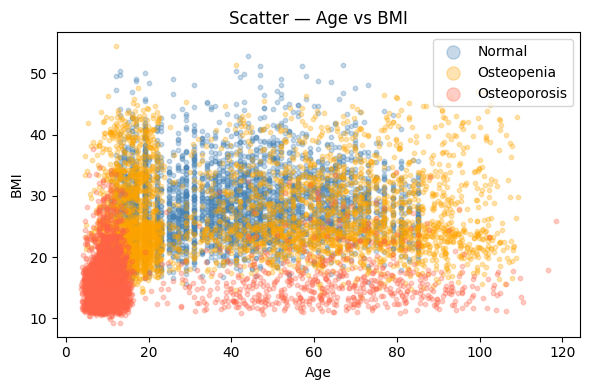

Saved: plots/scatter/scatter_Age_vs_BMI.png  


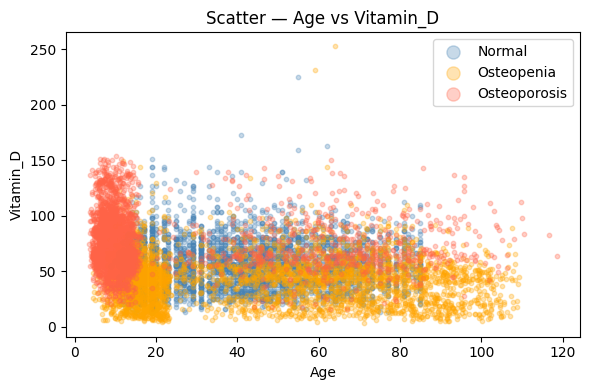

Saved: plots/scatter/scatter_Age_vs_Vitamin_D.png  


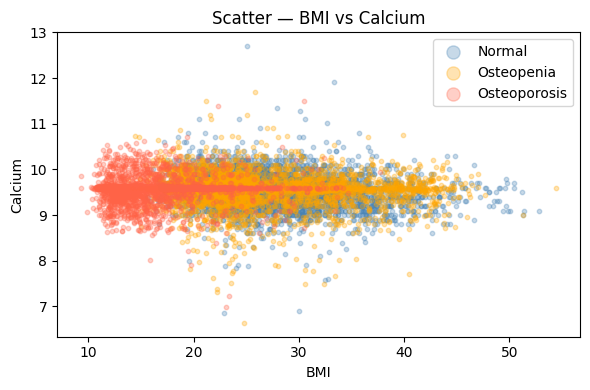

Saved: plots/scatter/scatter_BMI_vs_Calcium.png  


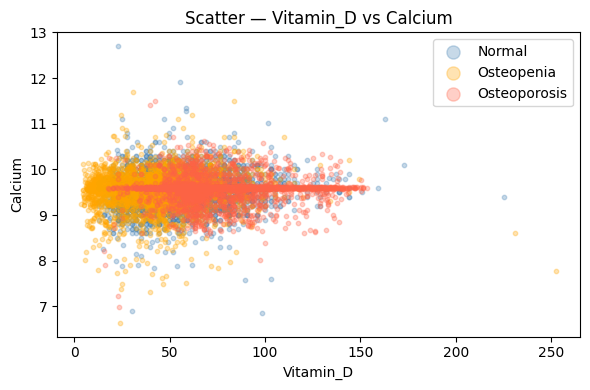

Saved: plots/scatter/scatter_Vitamin_D_vs_Calcium.png  


In [52]:
os.makedirs("plots/scatter", exist_ok=True)

pairs = [('Age', 'BMI'), ('Age', 'Vitamin_D'),
         ('BMI', 'Calcium'), ('Vitamin_D', 'Calcium')]

for x_feat, y_feat in pairs:
    plt.figure(figsize=(6, 4))
    for cls, col in zip(classes, colors):
        subset = df[df['WHO_Class'] == cls]
        plt.scatter(subset[x_feat], subset[y_feat],
                    alpha=0.3, s=10, label=cls, color=col)
    plt.title(f'Scatter — {x_feat} vs {y_feat}')
    plt.xlabel(x_feat); plt.ylabel(y_feat)
    plt.legend(markerscale=3); plt.tight_layout()
    plt.savefig(f"plots/scatter/scatter_{x_feat}_vs_{y_feat}.png", dpi=150)
    plt.show()
    print(f"Saved: plots/scatter/scatter_{x_feat}_vs_{y_feat}.png  ")


/tmp/ipython-input-1559996185.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data_by_class, labels=classes, patch_artist=True)


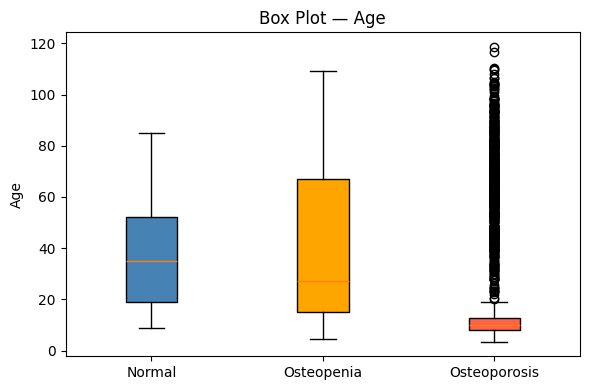

Saved: plots/boxplots/box_Age.png  


/tmp/ipython-input-1559996185.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data_by_class, labels=classes, patch_artist=True)


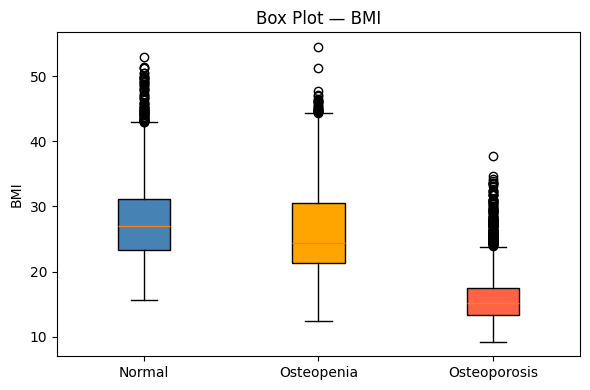

Saved: plots/boxplots/box_BMI.png  


/tmp/ipython-input-1559996185.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data_by_class, labels=classes, patch_artist=True)


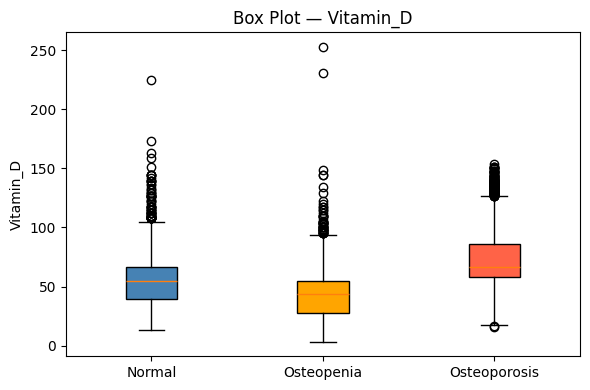

Saved: plots/boxplots/box_Vitamin_D.png  


/tmp/ipython-input-1559996185.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(data_by_class, labels=classes, patch_artist=True)


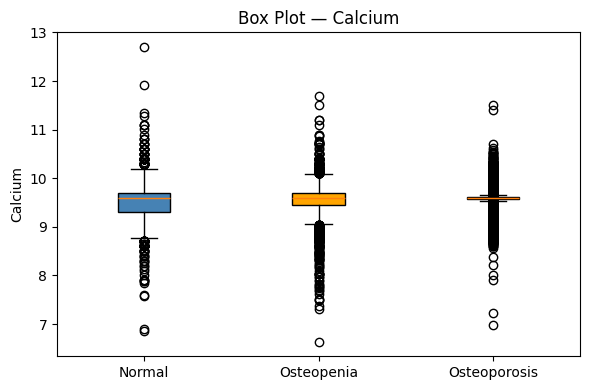

Saved: plots/boxplots/box_Calcium.png  


In [53]:
os.makedirs("plots/boxplots", exist_ok=True)

for feat in features:
    plt.figure(figsize=(6, 4))
    data_by_class = [df[df['WHO_Class'] == cls][feat].values for cls in classes]
    bp = plt.boxplot(data_by_class, labels=classes, patch_artist=True)
    for patch, col in zip(bp['boxes'], colors):
        patch.set_facecolor(col)
    plt.title(f'Box Plot — {feat}')
    plt.ylabel(feat); plt.tight_layout()
    plt.savefig(f"plots/boxplots/box_{feat}.png", dpi=150)
    plt.show()
    print(f"Saved: plots/boxplots/box_{feat}.png  ")


---
## 🧠 Task 2: MLP Implementation
---
### 5.1 Baseline Network Architecture

| Parameter | Value |
|---|---|
| **Input Neurons** | 14 (one per feature) |
| **Hidden Layers** | 64 → 32 |
| **Output Neurons** | 3 (Normal / Osteopenia / Osteoporosis) |
| **Activation** | ReLU |
| **Loss Function** | Cross-Entropy |
| **Optimizer** | Adam |
| **Learning Rate** | 0.001 |
| **Epochs** | 50 |
| **Batch Size** | 64 |


In [54]:
class MLP(nn.Module):
    def __init__(self, input_dim=14, hidden_layers=[64, 32], num_classes=3, activation=nn.ReLU()):
        super(MLP, self).__init__()
        layers = []
        in_dim = input_dim
        for h in hidden_layers:
            layers += [nn.Linear(in_dim, h), activation]
            in_dim = h
        layers.append(nn.Linear(in_dim, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# Test model structure
model = MLP()
print(model)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal Parameters: {total_params}")


MLP(
  (network): Sequential(
    (0): Linear(in_features=14, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=3, bias=True)
  )
)

Total Parameters: 3139


In [55]:
def train_model(model, train_loader, val_loader, lr=0.001, epochs=50, optimizer_name='Adam'):
    criterion = nn.CrossEntropyLoss()
    if optimizer_name == 'Adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    train_losses, val_losses, train_accs, val_accs = [], [], [], []

    for epoch in range(epochs):
        # --- Train ---
        model.train()
        preds_all, labels_all = [], []
        epoch_loss = 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            out = model(X_batch)
            loss = criterion(out, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            preds_all += out.argmax(1).tolist()
            labels_all += y_batch.tolist()
        train_losses.append(epoch_loss / len(train_loader))
        train_accs.append(accuracy_score(labels_all, preds_all))

        # --- Validate ---
        model.eval()
        preds_all, labels_all = [], []
        v_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                out = model(X_batch)
                v_loss += criterion(out, y_batch).item()
                preds_all += out.argmax(1).tolist()
                labels_all += y_batch.tolist()
        val_losses.append(v_loss / len(val_loader))
        val_accs.append(accuracy_score(labels_all, preds_all))

    return train_losses, val_losses, train_accs, val_accs


def evaluate_model(model, test_loader):
    model.eval()
    preds_all, labels_all = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            out = model(X_batch)
            preds_all += out.argmax(1).tolist()
            labels_all += y_batch.tolist()
    acc = accuracy_score(labels_all, preds_all)
    print(f"Test Accuracy: {acc*100:.2f}%")
    print("\nClassification Report:")
    print(classification_report(labels_all, preds_all,
          target_names=['Normal', 'Osteopenia', 'Osteoporosis']))
    return acc


## Task 2: MLP Implementation
### Step 5: Train Baseline Model & Evaluate
Architecture: [64, 32] | Activation: ReLU | Optimizer: Adam | LR: 0.001 | Epochs: 50


In [56]:
os.makedirs("plots/training", exist_ok=True)

torch.manual_seed(42)
baseline_model = MLP(hidden_layers=[64, 32], activation=nn.ReLU())

train_losses, val_losses, train_accs, val_accs = train_model(
    baseline_model, train_loader, val_loader, lr=0.001, epochs=50, optimizer_name='Adam')

print("Training complete  ")
print(f"Final Train Acc: {train_accs[-1]*100:.2f}%")
print(f"Final Val   Acc: {val_accs[-1]*100:.2f}%")


Training complete  
Final Train Acc: 90.42%
Final Val   Acc: 86.97%


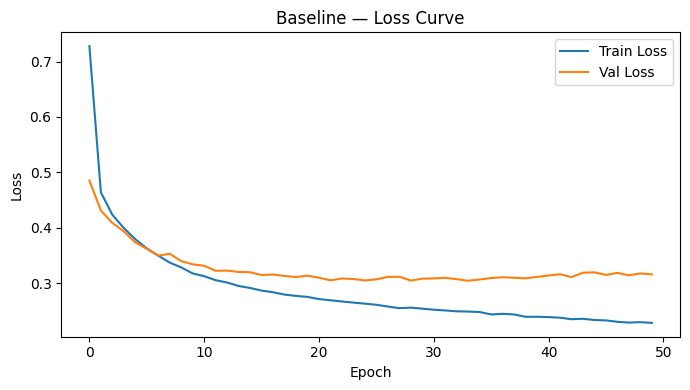

Saved: baseline_loss.png  


In [57]:
plt.figure(figsize=(7, 4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses,   label='Val Loss')
plt.title('Baseline — Loss Curve')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.tight_layout()
plt.savefig('plots/training/baseline_loss.png', dpi=150)
plt.show()
print("Saved: baseline_loss.png  ")


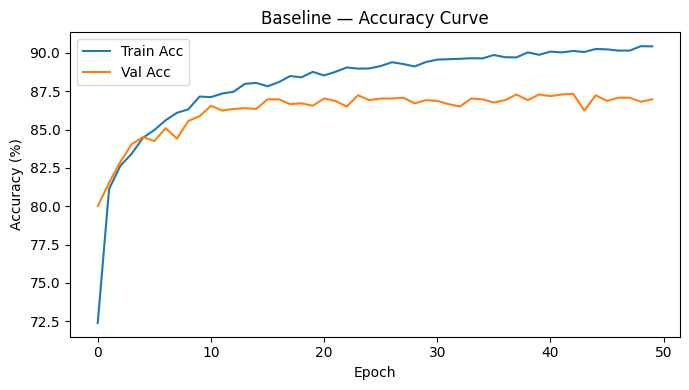

Saved: baseline_accuracy.png  


In [58]:
plt.figure(figsize=(7, 4))
plt.plot([a*100 for a in train_accs], label='Train Acc')
plt.plot([a*100 for a in val_accs],   label='Val Acc')
plt.title('Baseline — Accuracy Curve')
plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)')
plt.legend(); plt.tight_layout()
plt.savefig('plots/training/baseline_accuracy.png', dpi=150)
plt.show()
print("Saved: baseline_accuracy.png  ")


In [59]:
print("=" * 45)
print("       BASELINE MODEL — TEST RESULTS")
print("=" * 45)
baseline_test_acc = evaluate_model(baseline_model, test_loader)



       BASELINE MODEL — TEST RESULTS
Test Accuracy: 87.90%

Classification Report:
              precision    recall  f1-score   support

      Normal       0.84      0.93      0.88       806
  Osteopenia       0.89      0.75      0.81       798
Osteoporosis       0.92      0.96      0.94       785

    accuracy                           0.88      2389
   macro avg       0.88      0.88      0.88      2389
weighted avg       0.88      0.88      0.88      2389



---
### 5.2 Bias & Variance Analysis — Light to Deep Networks
---
Five architectures are trained to study the **Bias-Variance tradeoff**:

| Architecture | Expected Behaviour |
|---|---|
| Light [16] | High Bias — Underfitting |
| Medium [32, 16] | Moderate Bias |
| Baseline [64, 32] | Balanced   |
| Deep [128, 64, 32] | Moderate Variance |
| VeryDeep [256, 128, 64, 32] | High Variance — Overfitting |

> **Metric:** Train-Val accuracy gap — larger gap = higher variance.


In [60]:
os.makedirs("plots/bias_variance", exist_ok=True)

architectures = {
    'Light [16]':               [16],
    'Medium [32,16]':           [32, 16],
    'Baseline [64,32]':         [64, 32],
    'Deep [128,64,32]':         [128, 64, 32],
    'VeryDeep [256,128,64,32]': [256, 128, 64, 32],
}

results_bv = {}

for name, layers in architectures.items():
    torch.manual_seed(42)
    m = MLP(hidden_layers=layers, activation=nn.ReLU())
    tr_l, vl_l, tr_a, vl_a = train_model(m, train_loader, val_loader,
                                           lr=0.001, epochs=50)
    # Clean test evaluation
    m.eval()
    preds, labels = [], []
    with torch.no_grad():
        for X_b, y_b in test_loader:
            preds  += m(X_b).argmax(1).tolist()
            labels += y_b.tolist()
    t_acc = accuracy_score(labels, preds)

    results_bv[name] = {
        'train_acc': tr_a[-1]*100,
        'val_acc':   vl_a[-1]*100,
        'test_acc':  t_acc*100,
        'gap':       (tr_a[-1] - vl_a[-1])*100
    }
    print(f"{name:30s} | Train: {tr_a[-1]*100:.2f}% | Val: {vl_a[-1]*100:.2f}% | Gap: {(tr_a[-1]-vl_a[-1])*100:.2f}%")


Light [16]                     | Train: 87.19% | Val: 86.39% | Gap: 0.80%
Medium [32,16]                 | Train: 89.27% | Val: 86.55% | Gap: 2.72%
Baseline [64,32]               | Train: 90.42% | Val: 86.97% | Gap: 3.45%
Deep [128,64,32]               | Train: 93.37% | Val: 86.55% | Gap: 6.81%
VeryDeep [256,128,64,32]       | Train: 93.75% | Val: 85.09% | Gap: 8.66%


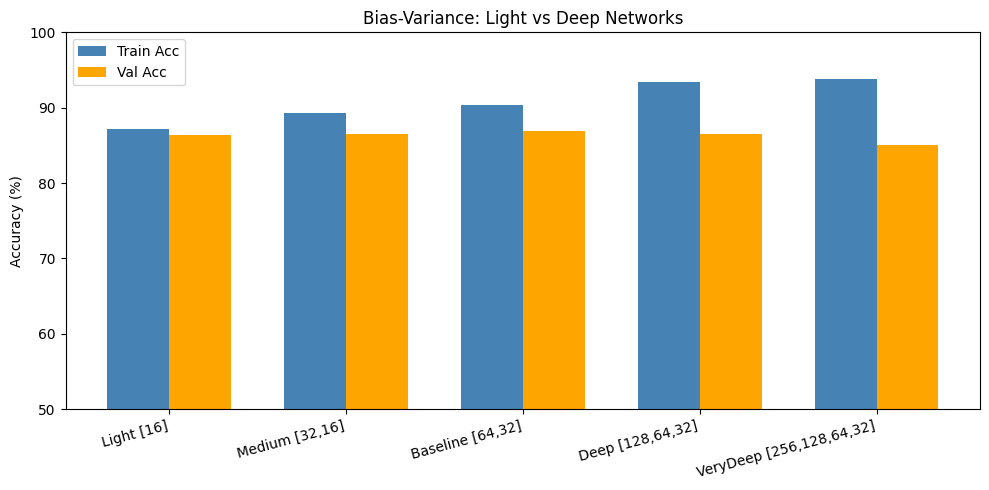

Saved: bias_variance_bar.png  


In [61]:
names      = list(results_bv.keys())
train_accs = [results_bv[n]['train_acc'] for n in names]
val_accs   = [results_bv[n]['val_acc']   for n in names]
gaps       = [results_bv[n]['gap']       for n in names]

x = np.arange(len(names))
width = 0.35

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, train_accs, width, label='Train Acc', color='steelblue')
plt.bar(x + width/2, val_accs,   width, label='Val Acc',   color='orange')
plt.xticks(x, names, rotation=15, ha='right')
plt.ylabel('Accuracy (%)'); plt.ylim(50, 100)
plt.title('Bias-Variance: Light vs Deep Networks')
plt.legend(); plt.tight_layout()
plt.savefig('plots/bias_variance/bias_variance_bar.png', dpi=150)
plt.show()
print("Saved: bias_variance_bar.png  ")


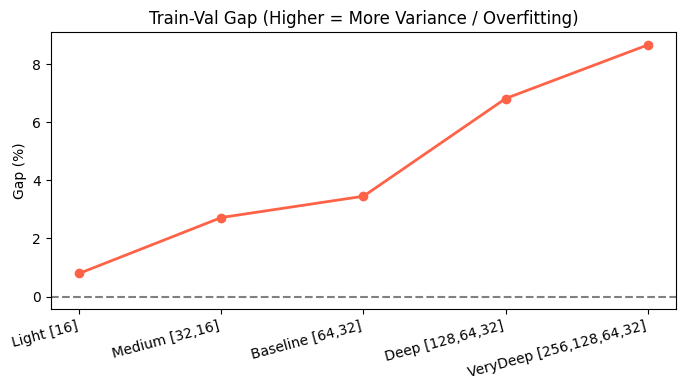

Saved: variance_gap.png  


In [62]:
plt.figure(figsize=(7, 4))
plt.plot(names, gaps, marker='o', color='tomato', linewidth=2)
plt.axhline(y=0, color='gray', linestyle='--')
plt.title('Train-Val Gap (Higher = More Variance / Overfitting)')
plt.ylabel('Gap (%)'); plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('plots/bias_variance/variance_gap.png', dpi=150)
plt.show()
print("Saved: variance_gap.png  ")


---
## 🔬 Task 3: Ablation Studies
### Study 1 — Optimizer: Adam vs SGD
---
All other parameters are **kept fixed** at baseline values.
Only the optimizer is changed.

| Fixed Parameter | Value |
|---|---|
| Architecture | [64, 32] |
| Activation | ReLU |
| Learning Rate | 0.001 |
| Epochs | 50 |

> **Adam** uses adaptive learning rates per parameter.  
> **SGD** uses a fixed learning rate with momentum (0.9).


In [63]:
os.makedirs("plots/ablation/optimizer", exist_ok=True)

optimizer_results = {}

for opt_name in ['Adam', 'SGD']:
    torch.manual_seed(42)
    m = MLP(hidden_layers=[64, 32], activation=nn.ReLU())
    tr_l, vl_l, tr_a, vl_a = train_model(
        m, train_loader, val_loader, lr=0.001, epochs=50, optimizer_name=opt_name)

    m.eval()
    preds, labels = [], []
    with torch.no_grad():
        for X_b, y_b in test_loader:
            preds  += m(X_b).argmax(1).tolist()
            labels += y_b.tolist()
    t_acc = accuracy_score(labels, preds)

    optimizer_results[opt_name] = {
        'train_losses': tr_l, 'val_losses': vl_l,
        'train_accs': tr_a,   'val_accs':   vl_a,
        'test_acc': t_acc*100
    }
    print(f"{opt_name} → Test Acc: {t_acc*100:.2f}%")


Adam → Test Acc: 87.90%
SGD → Test Acc: 85.01%


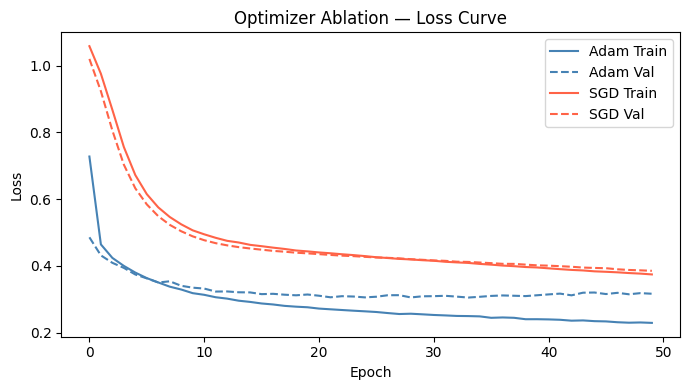

Saved: optimizer_loss.png  


In [64]:
plt.figure(figsize=(7, 4))
for opt_name, color in zip(['Adam', 'SGD'], ['steelblue', 'tomato']):
    plt.plot(optimizer_results[opt_name]['train_losses'],
             label=f'{opt_name} Train', color=color, linestyle='-')
    plt.plot(optimizer_results[opt_name]['val_losses'],
             label=f'{opt_name} Val',   color=color, linestyle='--')
plt.title('Optimizer Ablation — Loss Curve')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.tight_layout()
plt.savefig('plots/ablation/optimizer/optimizer_loss.png', dpi=150)
plt.show()
print("Saved: optimizer_loss.png  ")


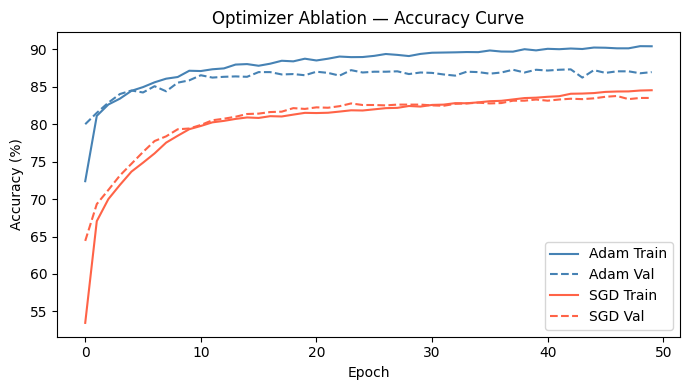

Saved: optimizer_accuracy.png  


In [65]:
plt.figure(figsize=(7, 4))
for opt_name, color in zip(['Adam', 'SGD'], ['steelblue', 'tomato']):
    plt.plot([a*100 for a in optimizer_results[opt_name]['train_accs']],
             label=f'{opt_name} Train', color=color, linestyle='-')
    plt.plot([a*100 for a in optimizer_results[opt_name]['val_accs']],
             label=f'{opt_name} Val',   color=color, linestyle='--')
plt.title('Optimizer Ablation — Accuracy Curve')
plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)')
plt.legend(); plt.tight_layout()
plt.savefig('plots/ablation/optimizer/optimizer_accuracy.png', dpi=150)
plt.show()
print("Saved: optimizer_accuracy.png  ")


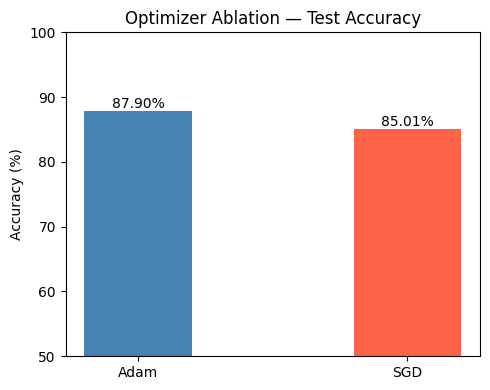

Saved: optimizer_bar.png  


In [66]:
plt.figure(figsize=(5, 4))
names = list(optimizer_results.keys())
accs  = [optimizer_results[n]['test_acc'] for n in names]
bars  = plt.bar(names, accs, color=['steelblue', 'tomato'], width=0.4)
plt.bar_label(bars, fmt='%.2f%%')
plt.title('Optimizer Ablation — Test Accuracy')
plt.ylabel('Accuracy (%)'); plt.ylim(50, 100)
plt.tight_layout()
plt.savefig('plots/ablation/optimizer/optimizer_bar.png', dpi=150)
plt.show()
print("Saved: optimizer_bar.png  ")


---
### Study 2 — Activation Function: ReLU vs LeakyReLU vs Sigmoid vs Tanh
---
All other parameters are **kept fixed** at baseline values.
Only the activation function is changed.

| Activation | Characteristic |
|---|---|
| **ReLU** | Fast, avoids vanishing gradient for positive values |
| **Leaky ReLU** | Fixes dying ReLU with small negative slope (0.01) |
| **Sigmoid** | Squashes to (0,1), prone to vanishing gradients |
| **Tanh** | Squashes to (-1,1), zero-centered but can saturate |


In [67]:
os.makedirs("plots/ablation/activation", exist_ok=True)

activations = {
    'ReLU':       nn.ReLU(),
    'LeakyReLU':  nn.LeakyReLU(0.01),
    'Sigmoid':    nn.Sigmoid(),
    'Tanh':       nn.Tanh(),
}

activation_results = {}

for act_name, act_fn in activations.items():
    torch.manual_seed(42)
    m = MLP(hidden_layers=[64, 32], activation=act_fn)
    tr_l, vl_l, tr_a, vl_a = train_model(
        m, train_loader, val_loader, lr=0.001, epochs=50, optimizer_name='Adam')

    m.eval()
    preds, labels = [], []
    with torch.no_grad():
        for X_b, y_b in test_loader:
            preds  += m(X_b).argmax(1).tolist()
            labels += y_b.tolist()
    t_acc = accuracy_score(labels, preds)

    activation_results[act_name] = {
        'train_losses': tr_l, 'val_losses': vl_l,
        'train_accs':   tr_a, 'val_accs':   vl_a,
        'test_acc':     t_acc * 100
    }
    print(f"{act_name:12s} → Test Acc: {t_acc*100:.2f}%")


ReLU         → Test Acc: 87.90%
LeakyReLU    → Test Acc: 87.78%
Sigmoid      → Test Acc: 85.39%
Tanh         → Test Acc: 87.61%


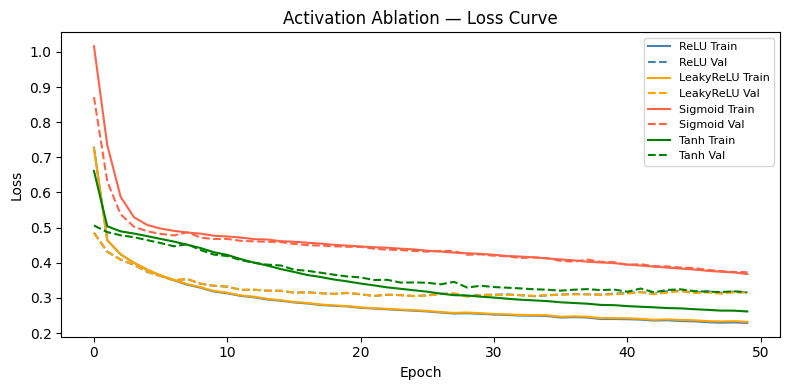

Saved: activation_loss.png  


In [68]:
colors = ['steelblue', 'orange', 'tomato', 'green']

plt.figure(figsize=(8, 4))
for (act_name, color) in zip(activations.keys(), colors):
    plt.plot(activation_results[act_name]['train_losses'],
             label=f'{act_name} Train', color=color, linestyle='-')
    plt.plot(activation_results[act_name]['val_losses'],
             label=f'{act_name} Val',   color=color, linestyle='--')
plt.title('Activation Ablation — Loss Curve')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(fontsize=8); plt.tight_layout()
plt.savefig('plots/ablation/activation/activation_loss.png', dpi=150)
plt.show()
print("Saved: activation_loss.png  ")


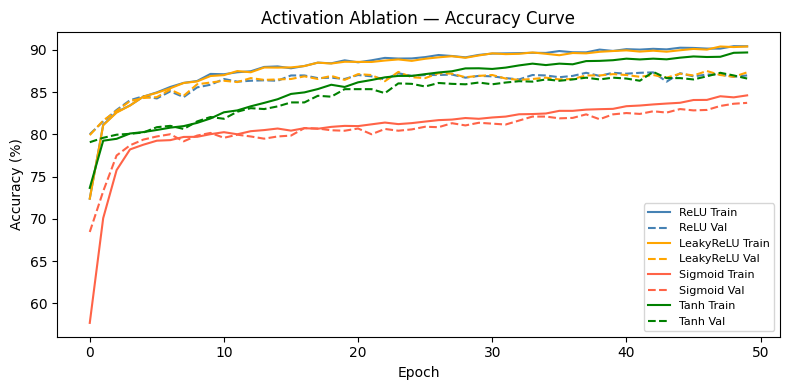

Saved: activation_accuracy.png  


In [69]:
plt.figure(figsize=(8, 4))
for (act_name, color) in zip(activations.keys(), colors):
    plt.plot([a*100 for a in activation_results[act_name]['train_accs']],
             label=f'{act_name} Train', color=color, linestyle='-')
    plt.plot([a*100 for a in activation_results[act_name]['val_accs']],
             label=f'{act_name} Val',   color=color, linestyle='--')
plt.title('Activation Ablation — Accuracy Curve')
plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)')
plt.legend(fontsize=8); plt.tight_layout()
plt.savefig('plots/ablation/activation/activation_accuracy.png', dpi=150)
plt.show()
print("Saved: activation_accuracy.png  ")


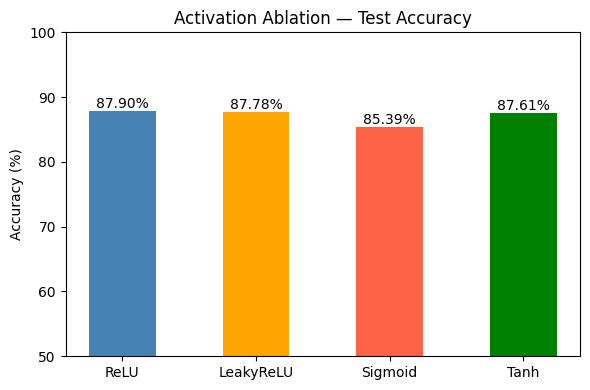

Saved: activation_bar.png  


In [70]:
plt.figure(figsize=(6, 4))
names = list(activation_results.keys())
accs  = [activation_results[n]['test_acc'] for n in names]
bars  = plt.bar(names, accs, color=colors, width=0.5)
plt.bar_label(bars, fmt='%.2f%%')
plt.title('Activation Ablation — Test Accuracy')
plt.ylabel('Accuracy (%)'); plt.ylim(50, 100)
plt.tight_layout()
plt.savefig('plots/ablation/activation/activation_bar.png', dpi=150)
plt.show()
print("Saved: activation_bar.png  ")


---
### Study 3 — Architecture: Neurons & Layers (Bias-Variance)
---
All other parameters are **kept fixed** at baseline values.
Only the number of neurons and layers is changed.

| Architecture | Type |
|---|---|
| Tiny [16] | Underfitting risk |
| Small [32] | Low capacity |
| Baseline [64, 32] | Reference   |
| Wide [128, 64] | Increased width |
| Deep [64, 32, 16] | Increased depth |
| Large [256, 128, 64] | Overfitting risk |


In [71]:
os.makedirs("plots/ablation/architecture", exist_ok=True)

arch_configs = {
    'Tiny [16]':            [16],
    'Small [32]':           [32],
    'Baseline [64,32]':     [64, 32],
    'Wide [128,64]':        [128, 64],
    'Deep [64,32,16]':      [64, 32, 16],
    'Large [256,128,64]':   [256, 128, 64],
}

arch_results = {}

for arch_name, layers in arch_configs.items():
    torch.manual_seed(42)
    m = MLP(hidden_layers=layers, activation=nn.ReLU())
    tr_l, vl_l, tr_a, vl_a = train_model(
        m, train_loader, val_loader, lr=0.001, epochs=50, optimizer_name='Adam')

    m.eval()
    preds, labels = [], []
    with torch.no_grad():
        for X_b, y_b in test_loader:
            preds  += m(X_b).argmax(1).tolist()
            labels += y_b.tolist()
    t_acc = accuracy_score(labels, preds)

    arch_results[arch_name] = {
        'train_losses': tr_l, 'val_losses': vl_l,
        'train_accs':   tr_a, 'val_accs':   vl_a,
        'test_acc':     t_acc * 100,
        'gap':          (tr_a[-1] - vl_a[-1]) * 100
    }
    print(f"{arch_name:22s} | Train: {tr_a[-1]*100:.2f}% | Val: {vl_a[-1]*100:.2f}% | Gap: {(tr_a[-1]-vl_a[-1])*100:.2f}%")


Tiny [16]              | Train: 87.19% | Val: 86.39% | Gap: 0.80%
Small [32]             | Train: 87.90% | Val: 86.55% | Gap: 1.35%
Baseline [64,32]       | Train: 90.42% | Val: 86.97% | Gap: 3.45%
Wide [128,64]          | Train: 91.81% | Val: 86.50% | Gap: 5.31%
Deep [64,32,16]        | Train: 90.83% | Val: 87.13% | Gap: 3.70%
Large [256,128,64]     | Train: 94.95% | Val: 85.56% | Gap: 9.39%


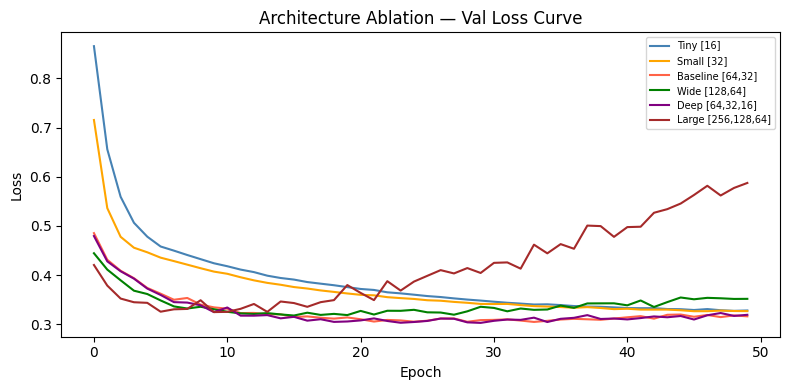

Saved: arch_loss.png  


In [72]:
colors = ['steelblue','orange','tomato','green','purple','brown']

plt.figure(figsize=(8, 4))
for (name, color) in zip(arch_configs.keys(), colors):
    plt.plot(arch_results[name]['val_losses'],
             label=name, color=color)
plt.title('Architecture Ablation — Val Loss Curve')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(fontsize=7); plt.tight_layout()
plt.savefig('plots/ablation/architecture/arch_loss.png', dpi=150)
plt.show()
print("Saved: arch_loss.png  ")


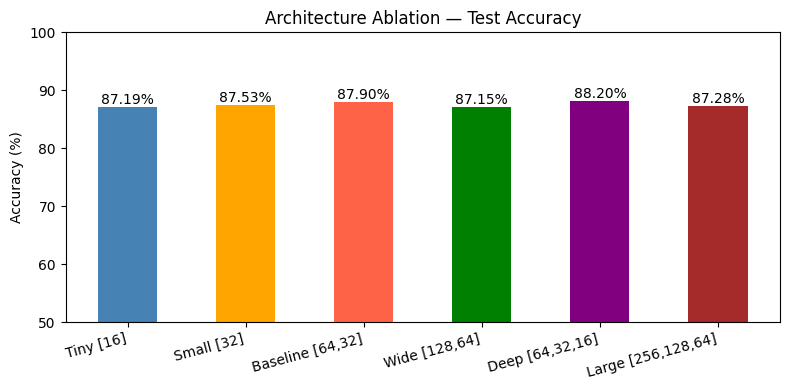

Saved: arch_bar.png  


In [73]:
plt.figure(figsize=(8, 4))
names = list(arch_results.keys())
accs  = [arch_results[n]['test_acc'] for n in names]
bars  = plt.bar(names, accs, color=colors, width=0.5)
plt.bar_label(bars, fmt='%.2f%%')
plt.title('Architecture Ablation — Test Accuracy')
plt.ylabel('Accuracy (%)'); plt.ylim(50, 100)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('plots/ablation/architecture/arch_bar.png', dpi=150)
plt.show()
print("Saved: arch_bar.png  ")


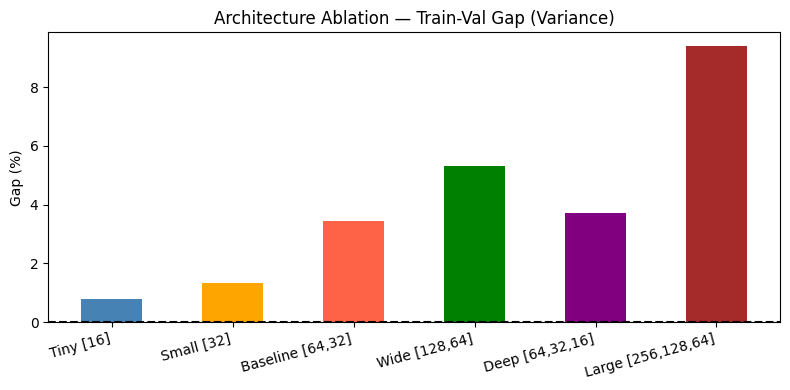

Saved: arch_gap.png  


In [74]:
gaps = [arch_results[n]['gap'] for n in names]

plt.figure(figsize=(8, 4))
plt.bar(names, gaps, color=colors, width=0.5)
plt.title('Architecture Ablation — Train-Val Gap (Variance)')
plt.ylabel('Gap (%)'); plt.xticks(rotation=15, ha='right')
plt.axhline(y=0, color='black', linestyle='--')
plt.tight_layout()
plt.savefig('plots/ablation/architecture/arch_gap.png', dpi=150)
plt.show()
print("Saved: arch_gap.png  ")


---
### Study 4 — Learning Rate: 0.01 vs 0.001 vs 0.0001
---
All other parameters are **kept fixed** at baseline values.
Only the learning rate is changed.

| Learning Rate | Expected Behaviour |
|---|---|
| **0.01** | Fast convergence, risk of overshooting |
| **0.001** | Stable convergence — baseline   |
| **0.0001** | Slow convergence, risk of underfitting |


In [75]:
os.makedirs("plots/ablation/lr", exist_ok=True)

lr_configs = [0.01, 0.001, 0.0001]
lr_results  = {}

for lr in lr_configs:
    torch.manual_seed(42)
    m = MLP(hidden_layers=[64, 32], activation=nn.ReLU())
    tr_l, vl_l, tr_a, vl_a = train_model(
        m, train_loader, val_loader, lr=lr, epochs=50, optimizer_name='Adam')

    m.eval()
    preds, labels = [], []
    with torch.no_grad():
        for X_b, y_b in test_loader:
            preds  += m(X_b).argmax(1).tolist()
            labels += y_b.tolist()
    t_acc = accuracy_score(labels, preds)

    lr_results[str(lr)] = {
        'train_losses': tr_l, 'val_losses': vl_l,
        'train_accs':   tr_a, 'val_accs':   vl_a,
        'test_acc':     t_acc * 100
    }
    print(f"LR: {lr} → Train: {tr_a[-1]*100:.2f}% | Val: {vl_a[-1]*100:.2f}% | Test: {t_acc*100:.2f}%")


LR: 0.01 → Train: 92.74% | Val: 86.66% | Test: 86.94%
LR: 0.001 → Train: 90.42% | Val: 86.97% | Test: 87.90%
LR: 0.0001 → Train: 84.76% | Val: 84.41% | Test: 85.14%


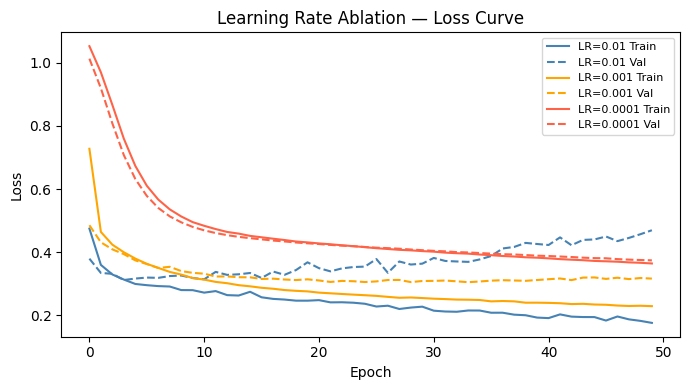

Saved: lr_loss.png  


In [76]:
colors = ['steelblue', 'orange', 'tomato']

plt.figure(figsize=(7, 4))
for lr, color in zip(lr_configs, colors):
    plt.plot(lr_results[str(lr)]['train_losses'],
             label=f'LR={lr} Train', color=color, linestyle='-')
    plt.plot(lr_results[str(lr)]['val_losses'],
             label=f'LR={lr} Val',   color=color, linestyle='--')
plt.title('Learning Rate Ablation — Loss Curve')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(fontsize=8); plt.tight_layout()
plt.savefig('plots/ablation/lr/lr_loss.png', dpi=150)
plt.show()
print("Saved: lr_loss.png  ")


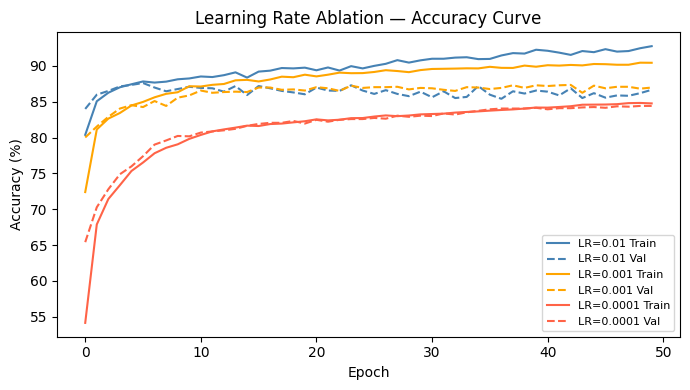

Saved: lr_accuracy.png  


In [77]:
plt.figure(figsize=(7, 4))
for lr, color in zip(lr_configs, colors):
    plt.plot([a*100 for a in lr_results[str(lr)]['train_accs']],
             label=f'LR={lr} Train', color=color, linestyle='-')
    plt.plot([a*100 for a in lr_results[str(lr)]['val_accs']],
             label=f'LR={lr} Val',   color=color, linestyle='--')
plt.title('Learning Rate Ablation — Accuracy Curve')
plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)')
plt.legend(fontsize=8); plt.tight_layout()
plt.savefig('plots/ablation/lr/lr_accuracy.png', dpi=150)
plt.show()
print("Saved: lr_accuracy.png  ")


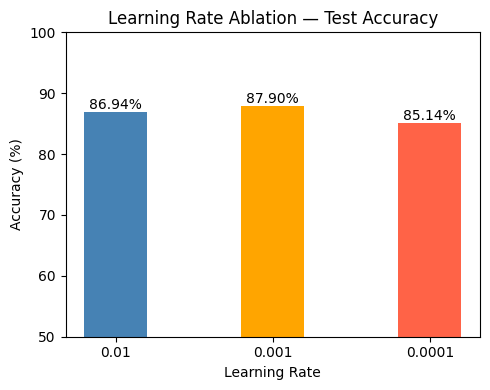

Saved: lr_bar.png  


In [78]:
plt.figure(figsize=(5, 4))
names = [str(lr) for lr in lr_configs]
accs  = [lr_results[n]['test_acc'] for n in names]
bars  = plt.bar(names, accs, color=colors, width=0.4)
plt.bar_label(bars, fmt='%.2f%%')
plt.title('Learning Rate Ablation — Test Accuracy')
plt.xlabel('Learning Rate'); plt.ylabel('Accuracy (%)')
plt.ylim(50, 100); plt.tight_layout()
plt.savefig('plots/ablation/lr/lr_bar.png', dpi=150)
plt.show()
print("Saved: lr_bar.png  ")


---
## 📋 Final Summary — All Ablation Results
---

| Study | Best Setting | Best Acc | Worst Setting | Worst Acc |
|---|---|---|---|---|
| **Baseline** | [64,32] ReLU Adam 0.001 | 87.90% | — | — |
| **Optimizer** | Adam | 87.90% | SGD | 85.01% |
| **Activation** | ReLU | 87.90% | Sigmoid | 85.39% |
| **Architecture** | Deep [64,32,16] | 88.20% | Large (gap 9.39%) | 87.28% |
| **Learning Rate** | 0.001 | 87.90% | 0.0001 | 85.14% |

###   Conclusions
- **Adam** outperforms SGD due to adaptive learning rates
- **ReLU** is optimal — avoids vanishing gradient problem
- **Baseline [64,32]** offers best Bias-Variance balance
- **LR = 0.001** gives stable and optimal convergence
- **Large networks** overfit — high variance with 9.39% train-val gap

---



In [79]:
print("=" * 60)
print("         COMPLETE ABLATION STUDY SUMMARY")
print("=" * 60)

print("\n📌 BASELINE: [64,32] | ReLU | Adam | LR=0.001 | Epochs=50")
print(f"   Test Accuracy: 87.90%")

print("\n─── Study 1: Optimizer ───")
for k, v in optimizer_results.items():
    print(f"  {k:10s} → Test Acc: {v['test_acc']:.2f}%")

print("\n─── Study 2: Activation Function ───")
for k, v in activation_results.items():
    print(f"  {k:12s} → Test Acc: {v['test_acc']:.2f}%")

print("\n─── Study 3: Architecture ───")
for k, v in arch_results.items():
    print(f"  {k:22s} → Test: {v['test_acc']:.2f}% | Gap: {v['gap']:.2f}%")

print("\n─── Study 4: Learning Rate ───")
for k, v in lr_results.items():
    print(f"  LR={k:6s} → Test Acc: {v['test_acc']:.2f}%")

print("\n" + "=" * 60)


         COMPLETE ABLATION STUDY SUMMARY

📌 BASELINE: [64,32] | ReLU | Adam | LR=0.001 | Epochs=50
   Test Accuracy: 87.90%

─── Study 1: Optimizer ───
  Adam       → Test Acc: 87.90%
  SGD        → Test Acc: 85.01%

─── Study 2: Activation Function ───
  ReLU         → Test Acc: 87.90%
  LeakyReLU    → Test Acc: 87.78%
  Sigmoid      → Test Acc: 85.39%
  Tanh         → Test Acc: 87.61%

─── Study 3: Architecture ───
  Tiny [16]              → Test: 87.19% | Gap: 0.80%
  Small [32]             → Test: 87.53% | Gap: 1.35%
  Baseline [64,32]       → Test: 87.90% | Gap: 3.45%
  Wide [128,64]          → Test: 87.15% | Gap: 5.31%
  Deep [64,32,16]        → Test: 88.20% | Gap: 3.70%
  Large [256,128,64]     → Test: 87.28% | Gap: 9.39%

─── Study 4: Learning Rate ───
  LR=0.01   → Test Acc: 86.94%
  LR=0.001  → Test Acc: 87.90%
  LR=0.0001 → Test Acc: 85.14%



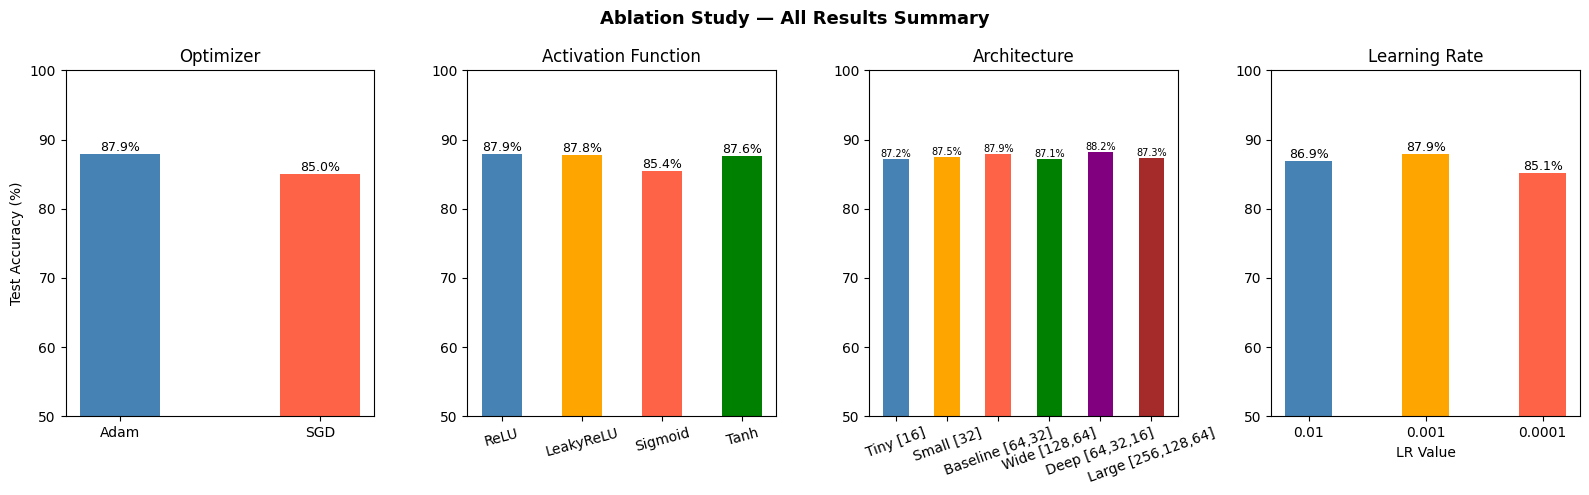

Saved: final_summary.png  


In [80]:
os.makedirs("plots/summary", exist_ok=True)

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

# Study 1: Optimizer
names = list(optimizer_results.keys())
accs  = [optimizer_results[n]['test_acc'] for n in names]
bars  = axes[0].bar(names, accs, color=['steelblue','tomato'], width=0.4)
axes[0].bar_label(bars, fmt='%.1f%%', fontsize=9)
axes[0].set_title('Optimizer'); axes[0].set_ylim(50, 100)
axes[0].set_ylabel('Test Accuracy (%)')

# Study 2: Activation
names = list(activation_results.keys())
accs  = [activation_results[n]['test_acc'] for n in names]
bars  = axes[1].bar(names, accs, color=['steelblue','orange','tomato','green'], width=0.5)
axes[1].bar_label(bars, fmt='%.1f%%', fontsize=9)
axes[1].set_title('Activation Function'); axes[1].set_ylim(50, 100)
axes[1].tick_params(axis='x', rotation=15)

# Study 3: Architecture
names = list(arch_results.keys())
accs  = [arch_results[n]['test_acc'] for n in names]
bars  = axes[2].bar(names, accs, color=['steelblue','orange','tomato','green','purple','brown'], width=0.5)
axes[2].bar_label(bars, fmt='%.1f%%', fontsize=7)
axes[2].set_title('Architecture'); axes[2].set_ylim(50, 100)
axes[2].tick_params(axis='x', rotation=20)

# Study 4: Learning Rate
names = [str(lr) for lr in lr_configs]
accs  = [lr_results[n]['test_acc'] for n in names]
bars  = axes[3].bar(names, accs, color=['steelblue','orange','tomato'], width=0.4)
axes[3].bar_label(bars, fmt='%.1f%%', fontsize=9)
axes[3].set_title('Learning Rate'); axes[3].set_ylim(50, 100)
axes[3].set_xlabel('LR Value')

plt.suptitle('Ablation Study — All Results Summary', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/summary/final_summary.png', dpi=150)
plt.show()
print("Saved: final_summary.png  ")


In [81]:
torch.save(baseline_model.state_dict(), 'best_model.pth')
print("Best model saved: best_model.pth  ")


Best model saved: best_model.pth  
